## Import Required Libraries

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint

## Display TensorFlow Version

In [2]:
print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


## Dataset Paths

In [3]:
train_dir = "dataset/Training"
test_dir = "dataset/Testing"

# Image Size and Batch Size

In [4]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

## Data Generator

In [5]:
train_datagen = ImageDataGenerator(rescale=1./255)

test_datagen = ImageDataGenerator(rescale=1./255)

## Load Training Data

In [6]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

Found 5602 images belonging to 4 classes.


## Load Testing Data

In [7]:
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 1601 images belonging to 4 classes.


## Create CNN Model

In [8]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation="relu", input_shape=(224,224,3)))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3), activation="relu"))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(128, (3,3), activation="relu"))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(256, activation="relu"))
model.add(Dropout(0.5))

model.add(Dense(128, activation="relu"))
model.add(Dropout(0.3))

model.add(Dense(4, activation="softmax"))

C:\Users\MY PC\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Display Model Summary

In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │      22,151,424 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 22,278,084 (84.98 MB)

 Trainable params: 22,278,084 (84.98 MB)

 Non-trainable params: 0 (0.00 B)

## Compile CNN Model

In [10]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

## Create EarlyStopping Callback

In [11]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

## Create ModelCheckpoint Callback

In [12]:
checkpoint = ModelCheckpoint(
    "model/brain_tumor_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

## Train CNN Model

In [13]:
history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=10,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 926ms/step - accuracy: 0.5350 - loss: 1.0747
Epoch 1: val_accuracy improved from None to 0.66334, saving model to model/brain_tumor_model.keras
176/176 ━━━━━━━━━━━━━━━━━━━━ 179s 1s/step - accuracy: 0.6517 - loss: 0.8382 - val_accuracy: 0.6633 - val_loss: 0.8487
Epoch 2/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8149 - loss: 0.4848
Epoch 2: val_accuracy improved from 0.66334 to 0.78951, saving model to model/brain_tumor_model.keras
176/176 ━━━━━━━━━━━━━━━━━━━━ 348s 2s/step - accuracy: 0.8333 - loss: 0.4561 - val_accuracy: 0.7895 - val_loss: 0.7782
Epoch 3/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 930ms/step - accuracy: 0.8771 - loss: 0.3297
Epoch 3: val_accuracy improved from 0.78951 to 0.81699, saving model to model/brain_tumor_model.keras
176/176 ━━━━━━━━━━━━━━━━━━━━ 175s 996ms/step - accuracy: 0.8824 - loss: 0.3106 - val_accuracy: 0.8170 - val_loss: 0.6298
Epoch 4/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9132 - loss: 0

## Save Final Model

In [14]:
model.save("brain_tumor_model.keras")

print("Model Saved Successfully")

Model Saved Successfully


## Evaluate Model

In [15]:
loss, accuracy = model.evaluate(test_generator)

print("Test Loss :", loss)
print("Test Accuracy :", accuracy)

51/51 ━━━━━━━━━━━━━━━━━━━━ 8s 157ms/step - accuracy: 0.8170 - loss: 0.6298
Test Loss : 0.6298401355743408
Test Accuracy : 0.8169893622398376


## Plot Training and Validation Accuracy

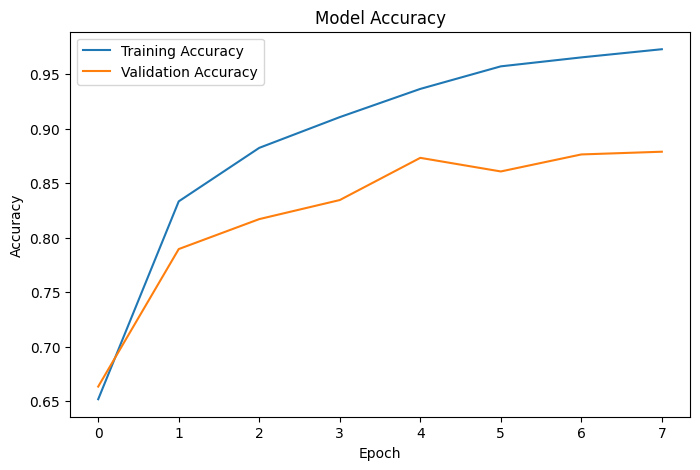

In [16]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

## Plot Training and Validation Loss

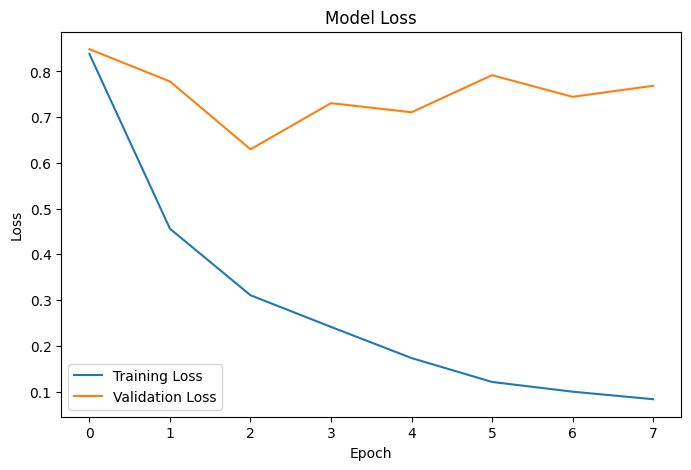

In [17]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

## Predict Test Dataset

In [18]:
predictions = model.predict(test_generator)

predicted_classes = np.argmax(predictions, axis=1)

true_classes = test_generator.classes

51/51 ━━━━━━━━━━━━━━━━━━━━ 8s 158ms/step


## Display Classification Report

In [19]:
from sklearn.metrics import classification_report

class_names = list(test_generator.class_indices.keys())

print(
    classification_report(
        true_classes,
        predicted_classes,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

      glioma       0.85      0.67      0.75       401
  meningioma       0.72      0.77      0.75       400
     notumor       0.78      0.96      0.86       400
   pituitary       0.96      0.87      0.91       400

    accuracy                           0.82      1601
   macro avg       0.83      0.82      0.82      1601
weighted avg       0.83      0.82      0.82      1601



## Display Confusion Matrix

In [20]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(true_classes, predicted_classes)

print(cm)

[[268  72  55   6]
 [ 26 309  56   9]
 [  5  11 384   0]
 [ 17  36   0 347]]


## Training Completed Successfully

In [21]:
print("=" * 50)
print("Brain Tumor CNN Model Training Completed Successfully")
print("=" * 50)

Brain Tumor CNN Model Training Completed Successfully
